# CrossDocked2020 — Density Data Coverage

For every unique PDB ID in the CrossDocked2020 train+test splits, query
[PDBe Summary API](https://www.ebi.ac.uk/pdbe/api/pdb/entry/summary/{pdb_id})
to check whether associated density data exists.

| `experimental_method_class` | Density type |
|---|---|
| `x-ray` | Electron density (from structure factors, if deposited) |
| `em`    | Cryo-EM map (EMDB accession in `related_structures`) |
| `nmr`   | None |
| other   | Case-by-case |

In [1]:
import json
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import requests
import torch
from tqdm.notebook import tqdm

REPO      = Path("..")
DATA_DIR  = REPO / "voxbind" / "dataset" / "data"
CACHE_DIR = REPO / "notebook" / "data"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

CACHE_FILE  = CACHE_DIR / "pdbe_summary_cache.json"
PDBE_URL    = "https://www.ebi.ac.uk/pdbe/api/pdb/entry/summary/{pdb_id}"
MAX_WORKERS = 20
RETRY_WAIT  = 2.0

## 1. Load CrossDocked PDB IDs

In [2]:
def extract_pdb_id(pocket_id: str) -> str:
    return pocket_id.split("/")[1].split("_")[0].upper()

pdb_ids: set[str] = set()
split_counts = {}

for fname in ("data_train.pt", "data_test.pt"):
    path = DATA_DIR / fname
    if not path.exists():
        print(f"  [SKIP] {fname} not found")
        continue
    samples = torch.load(path, weights_only=False)
    ids = {extract_pdb_id(pocket["id"]) for pocket, _ in samples}
    split_counts[fname] = len(ids)
    pdb_ids |= ids
    print(f"  {fname}: {len(samples):,} samples, {len(ids):,} unique PDB IDs")

pdb_ids = sorted(pdb_ids)
print(f"\nTotal unique PDB IDs: {len(pdb_ids):,}")

  data_train.pt: 99,981 samples, 14,635 unique PDB IDs
  data_test.pt: 100 samples, 100 unique PDB IDs

Total unique PDB IDs: 14,735


## 2. Query PDBe Summary API (cached)

In [4]:
def fetch_summary(pdb_id: str, session: requests.Session) -> tuple[str, dict | None]:
    url = PDBE_URL.format(pdb_id=pdb_id.lower())
    for attempt in range(3):
        try:
            r = session.get(url, timeout=15)
            if r.status_code == 200:
                data = r.json()
                entry = data.get(pdb_id.lower(), [{}])[0]
                return pdb_id, entry
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(RETRY_WAIT * (attempt + 1))
                continue
            return pdb_id, None   # 404 → obsolete or wrong ID
        except Exception:
            time.sleep(RETRY_WAIT)
    return pdb_id, None


# Load cache
cache: dict[str, dict | None] = {}
if CACHE_FILE.exists():
    cache = json.loads(CACHE_FILE.read_text())
    print(f"Loaded cache: {len(cache):,} entries")

to_fetch = [p for p in pdb_ids if p not in cache]
print(f"To fetch: {len(to_fetch):,}")

if to_fetch:
    session = requests.Session()
    with tqdm(total=len(to_fetch), unit="PDB") as pbar:
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
            futs = {pool.submit(fetch_summary, p, session): p for p in to_fetch}
            for fut in as_completed(futs):
                pid, entry = fut.result()
                cache[pid] = entry
                pbar.update(1)

    CACHE_FILE.write_text(json.dumps(cache, indent=2))
    print(f"Saved → {CACHE_FILE}")

print(f"Cache total: {len(cache):,} entries")

Loaded cache: 14,735 entries
To fetch: 0
Cache total: 14,735 entries


## 3. Parse Results

In [5]:
rows = []

for pid in pdb_ids:
    entry = cache.get(pid)
    if entry is None:
        rows.append({"pdb_id": pid, "method_class": "not_found",
                     "method": "not_found", "emdb_ids": [], "has_density": False,
                     "density_confirmed": False})
        continue

    method_class = entry.get("experimental_method_class", ["unknown"])
    method       = entry.get("experimental_method",       ["unknown"])
    related      = entry.get("related_structures", [])

    emdb_ids = [
        s["accession"] for s in related
        if isinstance(s, dict) and s.get("resource", "").upper() == "EMDB"
    ]

    mc = method_class[0].lower() if method_class else "unknown"

    # has_density: X-ray = *potentially* yes (structure factors may not be deposited).
    # density_confirmed: only True for EM (EMDB accession present).
    # A secondary EDS check is needed to confirm X-ray density (see cell below).
    has_density       = mc in ("x-ray", "em")
    density_confirmed = mc == "em" and bool(emdb_ids)

    rows.append({
        "pdb_id":           pid,
        "method_class":     mc,
        "method":           "; ".join(method),
        "emdb_ids":         emdb_ids,
        "has_density":      has_density,
        "density_confirmed": density_confirmed,
    })

df = pd.DataFrame(rows)
print(df["method_class"].value_counts().to_string())
print(f"\nNote: 'has_density' for X-ray is an upper bound — "
      f"structure factors are not always deposited (e.g. 132L, 1993).")

method_class
x-ray        14693
not_found       40
other            2

Note: 'has_density' for X-ray is an upper bound — structure factors are not always deposited (e.g. 132L, 1993).


## 4. Coverage Summary

In [5]:
total = len(df)
n_xray      = (df["method_class"] == "x-ray").sum()
n_em        = (df["method_class"] == "em").sum()
n_nmr       = (df["method_class"] == "nmr").sum()
n_other     = total - n_xray - n_em - n_nmr - (df["method_class"] == "not_found").sum()
n_not_found = (df["method_class"] == "not_found").sum()

sep = "─" * 56
print(sep)
print(f"  CrossDocked unique PDB IDs       : {total:>6,}")
print(sep)
print(f"  X-ray diffraction                : {n_xray:>6,}  ({100*n_xray/total:.1f}%)")
print(f"  Electron Microscopy (cryo-EM)    : {n_em:>6,}  ({100*n_em/total:.1f}%)")
print(f"  NMR                              : {n_nmr:>6,}  ({100*n_nmr/total:.1f}%)")
print(f"  Other                            : {n_other:>6,}  ({100*n_other/total:.1f}%)")
print(f"  Not found / obsolete             : {n_not_found:>6,}  ({100*n_not_found/total:.1f}%)")
print(sep)
print(f"  Upper bound (X-ray+EM method)    : {(n_xray+n_em):>6,}  ({100*(n_xray+n_em)/total:.1f}%)")
print(f"  Confirmed density (cryo-EM only) : {n_em:>6,}  ({100*n_em/total:.1f}%)")
print(sep)
print("  X-ray EDS actual coverage → see spot-check cell below.")

────────────────────────────────────────────────────────
  CrossDocked unique PDB IDs       : 14,735
────────────────────────────────────────────────────────
  X-ray diffraction                : 14,693  (99.7%)
  Electron Microscopy (cryo-EM)    :      0  (0.0%)
  NMR                              :      0  (0.0%)
  Other                            :      2  (0.0%)
  Not found / obsolete             :     40  (0.3%)
────────────────────────────────────────────────────────
  Upper bound (X-ray+EM method)    : 14,693  (99.7%)
  Confirmed density (cryo-EM only) :      0  (0.0%)
────────────────────────────────────────────────────────
  X-ray EDS actual coverage → see spot-check cell below.


## 5. Method Distribution



For each X-ray PDB ID, call:
`https://www.ebi.ac.uk/pdbe/api/pdb/entry/electron_density_statistics/{pdb_id}`

HTTP **200** indicates deposited structure factors and available EDS map.
This is the actual per-entry check (not an upper-bound estimate).

In [6]:
EDS_CACHE_FILE = CACHE_DIR / "pdbe_eds_cache.json"
EDS_URL        = "https://www.ebi.ac.uk/pdbe/api/pdb/entry/electron_density_statistics/{pdb_id}"

xray_ids = df[df["method_class"] == "x-ray"]["pdb_id"].tolist()

# Load cache
eds_cache: dict[str, bool] = {}
if EDS_CACHE_FILE.exists():
    eds_cache = json.loads(EDS_CACHE_FILE.read_text())
    print(f"EDS cache loaded: {len(eds_cache):,} entries")

to_check = [p for p in xray_ids if p not in eds_cache]
print(f"Checking {len(xray_ids):,} X-ray IDs, {len(to_check):,} not yet cached")


def check_eds(pdb_id: str, session: requests.Session) -> tuple[str, bool]:
    url = EDS_URL.format(pdb_id=pdb_id.lower())
    for attempt in range(3):
        try:
            r = session.get(url, timeout=15)
            if r.status_code == 200:
                return pdb_id, True
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(RETRY_WAIT * (attempt + 1))
                continue
            return pdb_id, False
        except Exception:
            time.sleep(RETRY_WAIT)
    return pdb_id, False


if to_check:
    session = requests.Session()
    with tqdm(total=len(to_check), unit="PDB", desc="EDS full check") as pbar:
        with ThreadPoolExecutor(max_workers=MAX_WORKERS) as pool:
            futs = {pool.submit(check_eds, p, session): p for p in to_check}
            for fut in as_completed(futs):
                pid, has_eds = fut.result()
                eds_cache[pid] = has_eds
                pbar.update(1)
    EDS_CACHE_FILE.write_text(json.dumps(eds_cache, indent=2))

# Restrict to this benchmark's X-ray IDs
xray_eds = {p: bool(eds_cache.get(p, False)) for p in xray_ids}
df["xray_eds_available"] = df["pdb_id"].map(xray_eds)

n_total_xray = len(xray_ids)
n_has = sum(xray_eds.values())
n_no = n_total_xray - n_has
missing_xray_ids = sorted([p for p, ok in xray_eds.items() if not ok])

print(f"\nX-ray EDS full check ({n_total_xray:,} entries):")
print(f"  Has EDS map : {n_has:,}  ({100*n_has/n_total_xray:.1f}%)")
print(f"  No EDS map  : {n_no:,}  ({100*n_no/n_total_xray:.1f}%)")

print(f"\nPDB IDs with no X-ray EDS map ({len(missing_xray_ids):,}):")
print(missing_xray_ids)

EDS cache loaded: 396 entries
Checking 14,693 X-ray IDs, 14,297 not yet cached


EDS full check:   0%|          | 0/14297 [00:00<?, ?PDB/s]


X-ray EDS full check (14,693 entries):
  Has EDS map : 13,362  (90.9%)
  No EDS map  : 1,331  (9.1%)

PDB IDs with no X-ray EDS map (1,331):
['132L', '1A31', '1A35', '1A42', '1A4G', '1A4Q', '1A5H', '1A69', '1A82', '1A85', '1A86', '1A9P', '1A9S', '1A9T', '1AAX', '1AB8', '1ACM', '1ACO', '1AD4', '1ADD', '1ADE', '1ADL', '1ADY', '1AFK', '1AFL', '1AFS', '1AGM', '1AH6', '1AHB', '1AHG', '1AI3', '1AIA', '1AJ0', '1AJ2', '1AJZ', '1AKA', '1AKB', '1AKC', '1AMA', '1AMI', '1AMR', '1AMW', '1AN5', '1AN9', '1ANB', '1ANC', '1AND', '1AOB', '1AOE', '1APV', '1ARG', '1ARH', '1ART', '1ASC', '1AT1', '1ATR', '1ATS', '1AV5', '1AVG', '1AXM', '1AXW', '1AY0', '1AY5', '1AY8', '1AZ8', '1B09', '1B0M', '1B2Y', '1B3D', '1B4S', '1B56', '1B6V', '1B8N', '1B8O', '1B8Y', '1B99', '1B9I', '1BB6', '1BB7', '1BBR', '1BCX', '1BD0', '1BDU', '1BGX', '1BH2', '1BHS', '1BID', '1BIL', '1BIM', '1BIW', '1BJI', '1BKC', '1BMA', '1BN3', '1BN5', '1BNM', '1BNN', '1BNT', '1BO8', '1BOZ', '1BP6', '1BPB', '1BPE', '1BPJ', '1BQ2', '1BQM', '1BQO', '

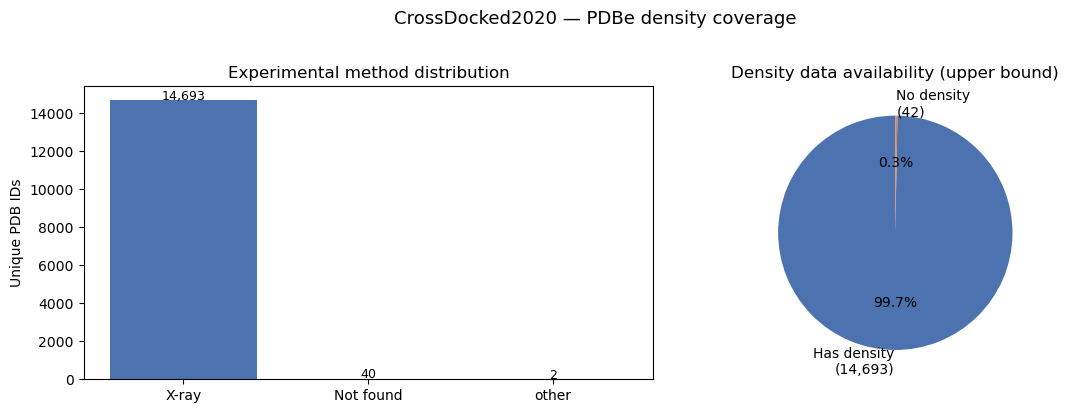

In [7]:
counts = df["method_class"].value_counts()

label_map = {
    "x-ray":     "X-ray",
    "em":         "cryo-EM",
    "nmr":        "NMR",
    "not_found":  "Not found",
}
labels = [label_map.get(k, k) for k in counts.index]
colors = ["#4C72B0", "#55A868", "#C44E52", "#8172B2", "#937860"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
axes[0].bar(labels, counts.values, color=colors[:len(counts)])
axes[0].set_title("Experimental method distribution")
axes[0].set_ylabel("Unique PDB IDs")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5, f"{v:,}", ha="center", fontsize=9)

# Pie: density vs no density (upper bound: X-ray or EM method)
# Use the same definition as in the text summary: has_density = (method_class in {"x-ray","em"}).
n_density = int(df["has_density"].sum())
pie_vals = [n_density, total - n_density]
pie_labs = [f"Has density\n({n_density:,})", f"No density\n({total - n_density:,})"]
axes[1].pie(pie_vals, labels=pie_labs, colors=["#4C72B0", "#DD8452"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Density data availability (upper bound)")

plt.suptitle("CrossDocked2020 — PDBe density coverage", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 6. Cryo-EM Entries with EMDB Accessions

In [ ]:
em_df = df[df["method_class"] == "em"].copy()

if em_df.empty:
    print("No cryo-EM structures found in CrossDocked2020.")
else:
    em_df["emdb_str"] = em_df["emdb_ids"].apply(lambda x: ", ".join(x) if x else "—")
    print(f"{len(em_df)} cryo-EM entries:")
    print(em_df[["pdb_id", "method", "emdb_str"]].to_string(index=False))

No cryo-EM structures found in CrossDocked2020.


## 7. X-ray Entries Sample

In [ ]:
xray_df = df[df["method_class"] == "x-ray"].copy()

if "xray_eds_available" not in df.columns:
    print("Run the 'X-ray EDS Full Check' cell first.")
else:
    has_eds_df = xray_df[xray_df["xray_eds_available"] == True]
    no_eds_df  = xray_df[xray_df["xray_eds_available"] == False]

    print(f"X-ray entries total          : {len(xray_df):,}")
    print(f"X-ray entries with EDS map   : {len(has_eds_df):,}")
    print(f"X-ray entries without EDS map: {len(no_eds_df):,}")
    print()
    print("PDB IDs without X-ray EDS map (first 50):")
    print(no_eds_df["pdb_id"].head(50).tolist())

14,693 X-ray entries — electron density maps available via PDBe EDS.

Sample (first 10):
pdb_id            method
  132L X-ray diffraction
  135L X-ray diffraction
  14GS X-ray diffraction
  1A0G X-ray diffraction
  1A18 X-ray diffraction
  1A26 X-ray diffraction
  1A27 X-ray diffraction
  1A28 X-ray diffraction
  1A2D X-ray diffraction
  1A2G X-ray diffraction

Note: X-ray electron density is typically accessible at:
  https://www.ebi.ac.uk/pdbe/entry/pdb/{pdb_id}/map


## 8. AHoJ Apo/Holo Classification

For every X-ray PDB ID with confirmed EDS density, query the
[AHoJ database](https://apoholo.cz) (`/api/db/search`) to find whether
the structure is classified as **apo** (ligand-free) or **holo** (ligand-bound),
and how many apo / holo counterparts exist in the PDB.

This is useful for X-ray finetuning: CrossDocked2020 entries should be
**holo** (structures solved with a bound ligand), and structures with
known **apo counterparts** offer paired training signal.

X-ray PDB IDs to check via AHoJ : 14,693
To fetch          : 14,693


AHoJ query:   0%|          | 0/14693 [00:00<?, ?PDB/s]

AHoJ cache saved → ../notebook/data/ahoj_cache.json  (14,693 new entries)


  0%|          | 0/14693 [00:00<?, ?it/s]

──────────────────────────────────────────────────────────
  X-ray EDS PDB IDs queried         :  14,693
──────────────────────────────────────────────────────────
  Found in AHoJ database            :       0  (0.0%)
  Not found in AHoJ                 :  14,693  (100.0%)
──────────────────────────────────────────────────────────
  Classification — holo             :       0  (0.0%)
  Classification — apo              :       0  (0.0%)
  Classification — mixed            :       0  (0.0%)
  Classification — unobserved       :       0  (0.0%)
──────────────────────────────────────────────────────────
  Has ≥1 apo counterpart in PDB     :       0  (0.0%)
──────────────────────────────────────────────────────────


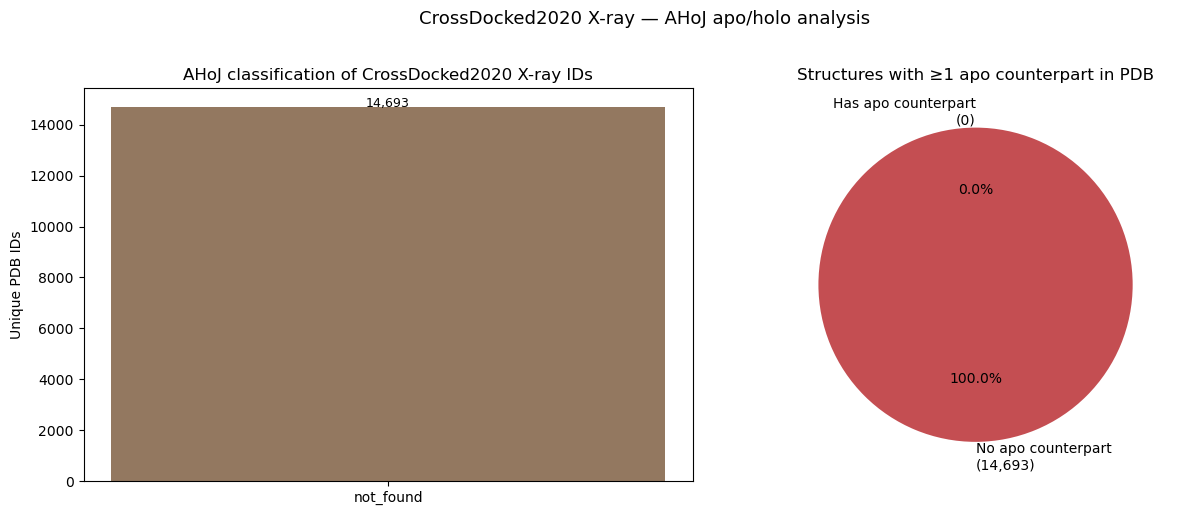


Median apo counterparts (for holo structures with ≥1 apo) : nan
Max    apo counterparts : 0


In [6]:
import json
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import matplotlib.pyplot as plt
import requests
from tqdm.notebook import tqdm

AHOJ_CACHE_FILE = CACHE_DIR / "ahoj_cache.json"
AHOJ_SEARCH_URL = "https://apoholo.cz/api/db/search"
AHOJ_BATCH      = 50     # PDB IDs per request (keep URLs short)
AHOJ_WORKERS    = 8
AHOJ_RETRY_WAIT = 2.0

# ── Work with X-ray PDB IDs that have confirmed EDS maps ──────────────────
if "xray_eds_available" in df.columns:
    ahoj_ids = sorted(df.loc[df["xray_eds_available"] == True, "pdb_id"].tolist())
else:
    ahoj_ids = sorted(df.loc[df["method_class"] == "x-ray", "pdb_id"].tolist())
print(f"X-ray PDB IDs to check via AHoJ : {len(ahoj_ids):,}")

# ── Load cache ─────────────────────────────────────────────────────────────
ahoj_cache: dict[str, list] = {}     # pdb_id -> list[DbEntry dicts]
if AHOJ_CACHE_FILE.exists():
    ahoj_cache = json.loads(AHOJ_CACHE_FILE.read_text())
    print(f"AHoJ cache loaded : {len(ahoj_cache):,} entries")

to_fetch = [p for p in ahoj_ids if p not in ahoj_cache]
print(f"To fetch          : {len(to_fetch):,}")

# ── Batch query function ───────────────────────────────────────────────────
def fetch_ahoj_batch(
    batch: list[str], session: requests.Session
) -> tuple[list[str], list[dict]]:
    """Query AHoJ /api/db/search for a batch of PDB IDs.
    Returns (batch, list_of_DbEntry_dicts)."""
    for attempt in range(3):
        try:
            r = session.get(
                AHOJ_SEARCH_URL,
                params={"pdb_ids": ",".join(batch)},
                timeout=30,
            )
            if r.status_code == 200:
                return batch, r.json() if isinstance(r.json(), list) else []
            if r.status_code in (429, 500, 502, 503, 504):
                time.sleep(AHOJ_RETRY_WAIT * (attempt + 1))
                continue
            return batch, []
        except Exception:
            time.sleep(AHOJ_RETRY_WAIT)
    return batch, []

# ── Run queries with caching ───────────────────────────────────────────────
if to_fetch:
    batches   = [to_fetch[i : i + AHOJ_BATCH] for i in range(0, len(to_fetch), AHOJ_BATCH)]
    session   = requests.Session()
    new_count = 0

    with tqdm(total=len(to_fetch), unit="PDB", desc="AHoJ query") as pbar:
        with ThreadPoolExecutor(max_workers=AHOJ_WORKERS) as pool:
            futs = {pool.submit(fetch_ahoj_batch, b, session): b for b in batches}
            for fut in as_completed(futs):
                batch, entries = fut.result()
                # Group returned entries by the target_pdb_id field
                batch_results: dict[str, list] = {p: [] for p in batch}
                for entry in entries:
                    pid = (entry.get("target_pdb_id") or "").upper()
                    if pid in batch_results:
                        batch_results[pid].append(entry)
                ahoj_cache.update(batch_results)
                new_count += len(batch)
                pbar.update(len(batch))

    AHOJ_CACHE_FILE.write_text(json.dumps(ahoj_cache, indent=2))
    print(f"AHoJ cache saved → {AHOJ_CACHE_FILE}  ({new_count:,} new entries)")

# ── Parse results ──────────────────────────────────────────────────────────
ahoj_rows = []
for pid in tqdm(ahoj_ids):
    entries = ahoj_cache.get(pid, [])
    if not entries:
        ahoj_rows.append({
            "pdb_id": pid, "in_ahoj": False,
            "classification": "not_found",
            "has_apo_counterpart": False,
            "num_apo_pdbs": 0, "num_holo_pdbs": 0,
        })
        continue

    # Aggregate across all chain+ligand entries for this PDB
    assignments = [e.get("target_apoholo_assignment", "") for e in entries]
    apo_counts  = [e.get("num_apo_pdbids",  0) or 0 for e in entries]
    holo_counts = [e.get("num_holo_pdbids", 0) or 0 for e in entries]

    unique_assign = set(a.lower() for a in assignments if a)
    if "holo" in unique_assign and "apo" in unique_assign:
        classification = "mixed"
    elif "holo" in unique_assign:
        classification = "holo"
    elif "apo" in unique_assign:
        classification = "apo"
    else:
        classification = "unobserved"

    ahoj_rows.append({
        "pdb_id":             pid,
        "in_ahoj":            True,
        "classification":     classification,
        "has_apo_counterpart": max(apo_counts) > 0,
        "num_apo_pdbs":       max(apo_counts),
        "num_holo_pdbs":      max(holo_counts),
    })

import pandas as pd
ahoj_df = pd.DataFrame(ahoj_rows)

# ── Summary ────────────────────────────────────────────────────────────────
n_total     = len(ahoj_df)
n_in_ahoj   = ahoj_df["in_ahoj"].sum()
n_holo      = (ahoj_df["classification"] == "holo").sum()
n_apo       = (ahoj_df["classification"] == "apo").sum()
n_mixed     = (ahoj_df["classification"] == "mixed").sum()
n_unobs     = (ahoj_df["classification"] == "unobserved").sum()
n_not_found = (ahoj_df["classification"] == "not_found").sum()
n_has_apo   = ahoj_df["has_apo_counterpart"].sum()

sep = "─" * 58
print(sep)
print(f"  X-ray EDS PDB IDs queried         : {n_total:>7,}")
print(sep)
print(f"  Found in AHoJ database            : {n_in_ahoj:>7,}  ({100*n_in_ahoj/n_total:.1f}%)")
print(f"  Not found in AHoJ                 : {n_not_found:>7,}  ({100*n_not_found/n_total:.1f}%)")
print(sep)
print(f"  Classification — holo             : {n_holo:>7,}  ({100*n_holo/n_total:.1f}%)")
print(f"  Classification — apo              : {n_apo:>7,}  ({100*n_apo/n_total:.1f}%)")
print(f"  Classification — mixed            : {n_mixed:>7,}  ({100*n_mixed/n_total:.1f}%)")
print(f"  Classification — unobserved       : {n_unobs:>7,}  ({100*n_unobs/n_total:.1f}%)")
print(sep)
print(f"  Has ≥1 apo counterpart in PDB     : {n_has_apo:>7,}  ({100*n_has_apo/n_total:.1f}%)")
print(sep)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Bar: classification breakdown
class_counts = ahoj_df["classification"].value_counts()
colors_map   = {
    "holo":       "#4C72B0",
    "apo":        "#55A868",
    "mixed":      "#DD8452",
    "unobserved": "#8172B2",
    "not_found":  "#937860",
}
bar_colors = [colors_map.get(k, "gray") for k in class_counts.index]
axes[0].bar(class_counts.index, class_counts.values, color=bar_colors)
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, f"{v:,}", ha="center", fontsize=9)
axes[0].set_title("AHoJ classification of CrossDocked2020 X-ray IDs")
axes[0].set_ylabel("Unique PDB IDs")

# Pie: has apo counterpart?
apo_pair_vals = [int(n_has_apo), int(n_total - n_has_apo)]
apo_pair_labs = [
    f"Has apo counterpart\n({n_has_apo:,})",
    f"No apo counterpart\n({n_total - n_has_apo:,})",
]
axes[1].pie(apo_pair_vals, labels=apo_pair_labs,
            colors=["#55A868", "#C44E52"],
            autopct="%1.1f%%", startangle=90)
axes[1].set_title("Structures with ≥1 apo counterpart in PDB")

plt.suptitle("CrossDocked2020 X-ray — AHoJ apo/holo analysis", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMedian apo counterparts (for holo structures with ≥1 apo) : "
      f"{ahoj_df.loc[ahoj_df['has_apo_counterpart'], 'num_apo_pdbs'].median():.0f}")
print(f"Max    apo counterparts : "
      f"{ahoj_df['num_apo_pdbs'].max():,}")